In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
print('Loading Data....')

data = pd.read_csv('train.csv', usecols=['Name', 'Ticket', 'Cabin'])

print('Data Loaded Successfully!')

Loading Data....
Data Loaded Successfully!


In [3]:
data.head()

,Name,Ticket,Cabin
0,"Braund, Mr. Owen Harris",A/5 21171,NaN
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",PC 17599,C85
2,"Heikkinen, Miss. Laina",STON/O2. 3101282,NaN
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",113803,C123
4,"Allen, Mr. William Henry",373450,NaN


In [4]:
s = data['Ticket'].str.split(' ', n=1, expand=True)
s.tail(10)

,0,1
881,349257,NaN
882,7552,NaN
883,C.A./SOTON,34068
884,SOTON/OQ,392076
885,382652,NaN
886,211536,NaN
887,112053,NaN
888,W./C.,6607
889,111369,NaN
890,370376,NaN


In [5]:
data['Ticket_Number'] = pd.to_numeric(s[0], errors='coerce', downcast='integer')

In [6]:
data['Ticket_cat'] = np.where(data['Ticket_Number'].isnull(), s[0], np.nan)

In [7]:
data

,Name,Ticket,Cabin,Ticket_Number,Ticket_cat
0,"Braund, Mr. Owen Harris",A/5 21171,NaN,NaN,A/5
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",PC 17599,C85,NaN,PC
2,"Heikkinen, Miss. Laina",STON/O2. 3101282,NaN,NaN,STON/O2.
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",113803,C123,113803.0,NaN
4,"Allen, Mr. William Henry",373450,NaN,373450.0,NaN
...,...,...,...,...,...
886,"Montvila, Rev. Juozas",211536,NaN,211536.0,NaN
887,"Graham, Miss. Margaret Edith",112053,B42,112053.0,NaN
888,"Johnston, Miss. Catherine Helen ""Carrie""",W./C. 6607,NaN,NaN,W./C.
889,"Behr, Mr. Karl Howell",111369,C148,111369.0,NaN


In [8]:
s = data['Name'].str.split(',', n=1, expand=True)
s

,0,1
0,Braund,Mr. Owen Harris
1,Cumings,Mrs. John Bradley (Florence Briggs Thayer)
2,Heikkinen,Miss. Laina
3,Futrelle,Mrs. Jacques Heath (Lily May Peel)
4,Allen,Mr. William Henry
...,...,...
886,Montvila,Rev. Juozas
887,Graham,Miss. Margaret Edith
888,Johnston,"Miss. Catherine Helen ""Carrie"""
889,Behr,Mr. Karl Howell


In [9]:
data['Name'] = s[1]
data['Brand'] = s[0]

data

,Name,Ticket,Cabin,Ticket_Number,Ticket_cat,Brand
0,Mr. Owen Harris,A/5 21171,NaN,NaN,A/5,Braund
1,Mrs. John Bradley (Florence Briggs Thayer),PC 17599,C85,NaN,PC,Cumings
2,Miss. Laina,STON/O2. 3101282,NaN,NaN,STON/O2.,Heikkinen
3,Mrs. Jacques Heath (Lily May Peel),113803,C123,113803.0,NaN,Futrelle
4,Mr. William Henry,373450,NaN,373450.0,NaN,Allen
...,...,...,...,...,...,...
886,Rev. Juozas,211536,NaN,211536.0,NaN,Montvila
887,Miss. Margaret Edith,112053,B42,112053.0,NaN,Graham
888,"Miss. Catherine Helen ""Carrie""",W./C. 6607,NaN,NaN,W./C.,Johnston
889,Mr. Karl Howell,111369,C148,111369.0,NaN,Behr


In [10]:
s[0] = data['Cabin'].str.extract('([a-zA-Z]+)')
s[1] = data['Cabin'].str.extract('(\d+)')

data['Cabin_cat'] = s[0]
data['Cabin_Number'] = s[1]
data

,Name,Ticket,Cabin,Ticket_Number,Ticket_cat,Brand,Cabin_cat,Cabin_Number
0,Mr. Owen Harris,A/5 21171,NaN,NaN,A/5,Braund,NaN,NaN
1,Mrs. John Bradley (Florence Briggs Thayer),PC 17599,C85,NaN,PC,Cumings,C,85
2,Miss. Laina,STON/O2. 3101282,NaN,NaN,STON/O2.,Heikkinen,NaN,NaN
3,Mrs. Jacques Heath (Lily May Peel),113803,C123,113803.0,NaN,Futrelle,C,123
4,Mr. William Henry,373450,NaN,373450.0,NaN,Allen,NaN,NaN
...,...,...,...,...,...,...,...,...
886,Rev. Juozas,211536,NaN,211536.0,NaN,Montvila,NaN,NaN
887,Miss. Margaret Edith,112053,B42,112053.0,NaN,Graham,B,42
888,"Miss. Catherine Helen ""Carrie""",W./C. 6607,NaN,NaN,W./C.,Johnston,NaN,NaN
889,Mr. Karl Howell,111369,C148,111369.0,NaN,Behr,C,148


In [11]:
data['Cabin_cat'].unique()

<ArrowStringArray>
[nan, 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T']
Length: 9, dtype: str

Text(0.5, 1.0, 'Travellers Cabin Category')

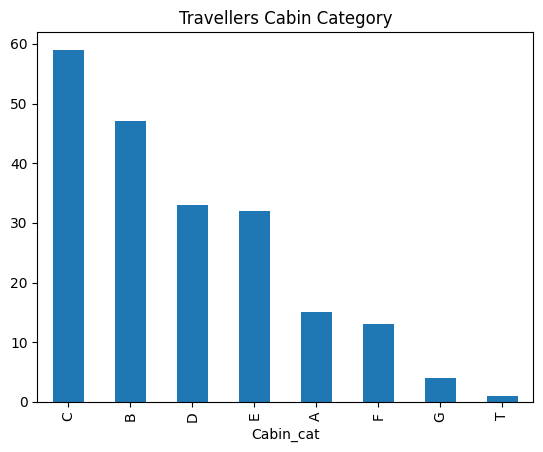

In [12]:
fig = data['Cabin_cat'].value_counts().plot(kind='bar')
fig.set_title('Travellers Cabin Category')

In [13]:
data['Ticket_cat'].unique()

<ArrowStringArray>
[       'A/5',         'PC',   'STON/O2.',          nan,         'PP',
       'A/5.',       'C.A.',      'A./5.',   'SC/Paris',  'S.C./A.4.',
       'A/4.',         'CA',       'S.P.',     'S.O.C.',       'SO/C',
      'W./C.',   'SOTON/OQ',     'W.E.P.',     'STON/O',        'A4.',
          'C', 'SOTON/O.Q.',   'SC/PARIS',     'S.O.P.',       'A.5.',
         'Fa',        'CA.',       'LINE',     'F.C.C.',        'W/C',
      'SW/PP',      'SCO/W',       'P/PP',         'SC',      'SC/AH',
        'A/S',        'A/4',       'WE/P',    'S.W./PP',  'S.O./P.P.',
       'F.C.',   'SOTON/O2', 'S.C./PARIS', 'C.A./SOTON']
Length: 44, dtype: str